# Modeling

In [17]:
import torch
import json
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Load splits
train_df = pd.read_csv("best-artworks-of-all-time/train.csv")
val_df   = pd.read_csv("best-artworks-of-all-time/val.csv")
test_df  = pd.read_csv("best-artworks-of-all-time/test.csv")

# Load label map
with open("data/style_labels.json", "r") as f:
    style_to_idx = json.load(f)
idx_to_style = {i: s for s, i in style_to_idx.items()}

# running on gpu macbook apple silicon
device = torch.device("mps")
print(f"Using device: {device}")
print(f"Styles: {list(style_to_idx.keys())}")

Using device: mps
Styles: ['Baroque', 'Cubism', 'Early Renaissance', 'Expressionism', 'Impressionism', 'Pop Art', 'Post-Impressionism', 'Primitivism', 'Realism', 'Renaissance', 'Romanticism', 'Suprematism', 'Surrealism', 'Symbolism']


In [18]:
# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class ArtDataset(Dataset):
    def __init__(self, dataframe, style_to_idx, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.style_to_idx = style_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = self.style_to_idx[row["style"]]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = ArtDataset(train_df, style_to_idx, transform=train_transforms)
val_dataset   = ArtDataset(val_df,   style_to_idx, transform=val_transforms)
test_dataset  = ArtDataset(test_df,  style_to_idx, transform=val_transforms)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size:   {len(val_dataset)}")
print(f"Test dataset size:  {len(test_dataset)}")

Train dataset size: 5912
Val dataset size:   1267
Test dataset size:  1267


In [19]:
# Weighted sampler to handle class imbalance
class_counts = train_df["style"].map(train_df["style"].value_counts()).values
sample_weights = torch.tensor(1.0 / class_counts, dtype=torch.float)

sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,   num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,   num_workers=0)

sanity check -- expect [32, 3, 224, 224] torch.float32

In [20]:
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")        
print(f"Dtype: {images.dtype}")              
print(f"Label sample: {[idx_to_style[l.item()] for l in labels[:8]]}")

Batch shape: torch.Size([32, 3, 224, 224])
Dtype: torch.float32
Label sample: ['Renaissance', 'Surrealism', 'Realism', 'Baroque', 'Surrealism', 'Realism', 'Pop Art', 'Cubism']


## Efficient Net set up

In [21]:
import timm
import torch.nn as nn

class ArtStyleClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load pretrained EfficientNet-B0 with no classification head
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        
        # Get the output feature size from the backbone
        num_features = self.backbone.num_features  # 1280 for EfficientNet-B0
        
        # Custom classification head
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)


num_classes = len(style_to_idx)
model = ArtStyleClassifier(num_classes=num_classes).to(device)

print(f"Number of classes: {num_classes}")
print(f"Model output size: {num_classes}")
print(f"Backbone output features: {model.backbone.num_features}")

Number of classes: 14
Model output size: 14
Backbone output features: 1280


In [22]:
import torch.optim as optim

# Loss — weighted to further penalize mistakes on rare styles
class_counts_tensor = torch.tensor(
    [train_df["style"].value_counts()[idx_to_style[i]] for i in range(num_classes)],
    dtype=torch.float
)
class_weights = (1.0 / class_counts_tensor).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler — reduces LR when val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)

print("Criterion, optimizer, and scheduler ready")

Criterion, optimizer, and scheduler ready


In [23]:
# Training loop
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

In [24]:
import torch
import os

# History tracking
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  []
}

# Early stopping config stop if no improvement for 3 epochs
EARLY_STOPPING_PATIENCE = 3   
best_val_loss = float("inf")
epochs_no_improve = 0
best_epoch = 0

NUM_EPOCHS = 20  

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc     = val_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    # Record metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} | "
          f"LR: {current_lr:.2e}")

    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "artifacts/best_model.pt")
        print(f"  ✓ Saved best model")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} epochs")

    # Early stopping check
    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\n Early stopping triggered at epoch {epoch+1}")
        print(f"  Best model was epoch {best_epoch} with val loss {best_val_loss:.4f}")
        break

print("\nTraining complete")

Epoch 01/20 | Train Loss: 1.6416 | Train Acc: 0.303 | Val Loss: 1.8856 | Val Acc: 0.182 | LR: 1.00e-04
  ✓ Saved best model
Epoch 02/20 | Train Loss: 0.7695 | Train Acc: 0.553 | Val Loss: 1.2855 | Val Acc: 0.357 | LR: 1.00e-04
  ✓ Saved best model
Epoch 03/20 | Train Loss: 0.4615 | Train Acc: 0.684 | Val Loss: 1.0448 | Val Acc: 0.443 | LR: 1.00e-04
  ✓ Saved best model
Epoch 04/20 | Train Loss: 0.2882 | Train Acc: 0.782 | Val Loss: 0.9166 | Val Acc: 0.583 | LR: 1.00e-04
  ✓ Saved best model
Epoch 05/20 | Train Loss: 0.2198 | Train Acc: 0.835 | Val Loss: 0.8435 | Val Acc: 0.661 | LR: 1.00e-04
  ✓ Saved best model
Epoch 06/20 | Train Loss: 0.1662 | Train Acc: 0.868 | Val Loss: 0.8070 | Val Acc: 0.672 | LR: 1.00e-04
  ✓ Saved best model
Epoch 07/20 | Train Loss: 0.1392 | Train Acc: 0.894 | Val Loss: 0.8367 | Val Acc: 0.687 | LR: 1.00e-04
  No improvement for 1/3 epochs
Epoch 08/20 | Train Loss: 0.1098 | Train Acc: 0.911 | Val Loss: 0.8063 | Val Acc: 0.725 | LR: 1.00e-04
  ✓ Saved best mod

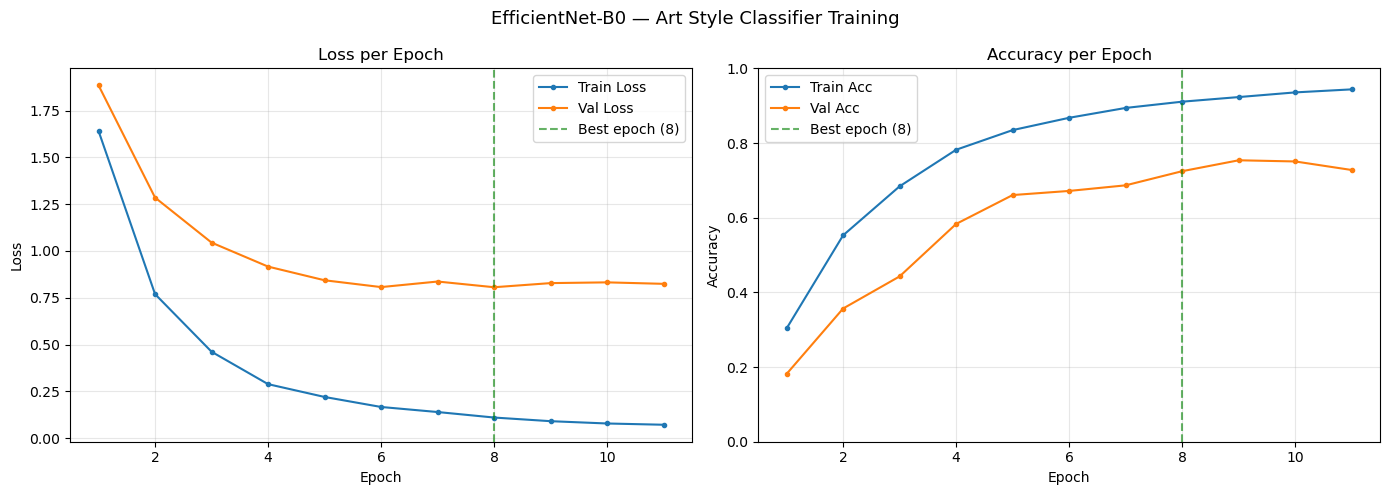

In [ ]:
import matplotlib.pyplot as plt
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_ran, history["train_loss"], label="Train Loss", marker="o", markersize=3)
ax1.plot(epochs_ran, history["val_loss"],   label="Val Loss",   marker="o", markersize=3)
ax1.axvline(x=best_epoch, color="green", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_ran, history["train_acc"], label="Train Acc", marker="o", markersize=3)
ax2.plot(epochs_ran, history["val_acc"],   label="Val Acc",   marker="o", markersize=3)
ax2.axvline(x=best_epoch, color="green", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("EfficientNet-B0 — Art Style Classifier Training", fontsize=13)
plt.tight_layout()
plt.show()


## Evaluation

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Load best model
model.load_state_dict(torch.load("artifacts/best_model.pt", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
accuracy = (all_preds == all_labels).mean()
print(f"Test Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)\n")

# Per-class breakdown
style_names = [idx_to_style[i] for i in range(num_classes)]
print(classification_report(all_labels, all_preds, target_names=style_names))

Test Accuracy: 0.737 (73.7%)

                    precision    recall  f1-score   support

           Baroque       0.59      0.86      0.70        88
            Cubism       0.68      0.64      0.66        66
 Early Renaissance       0.79      1.00      0.88        33
     Expressionism       0.72      0.79      0.75        86
     Impressionism       0.90      0.66      0.76       247
           Pop Art       0.96      0.89      0.92        27
Post-Impressionism       0.72      0.71      0.72       157
       Primitivism       0.73      0.82      0.77        65
           Realism       0.45      0.61      0.52        33
       Renaissance       0.90      0.71      0.80       223
       Romanticism       0.60      0.88      0.71        58
       Suprematism       0.88      0.74      0.80        19
        Surrealism       0.77      0.71      0.74        65
         Symbolism       0.59      0.72      0.65       100

          accuracy                           0.74      1267
        

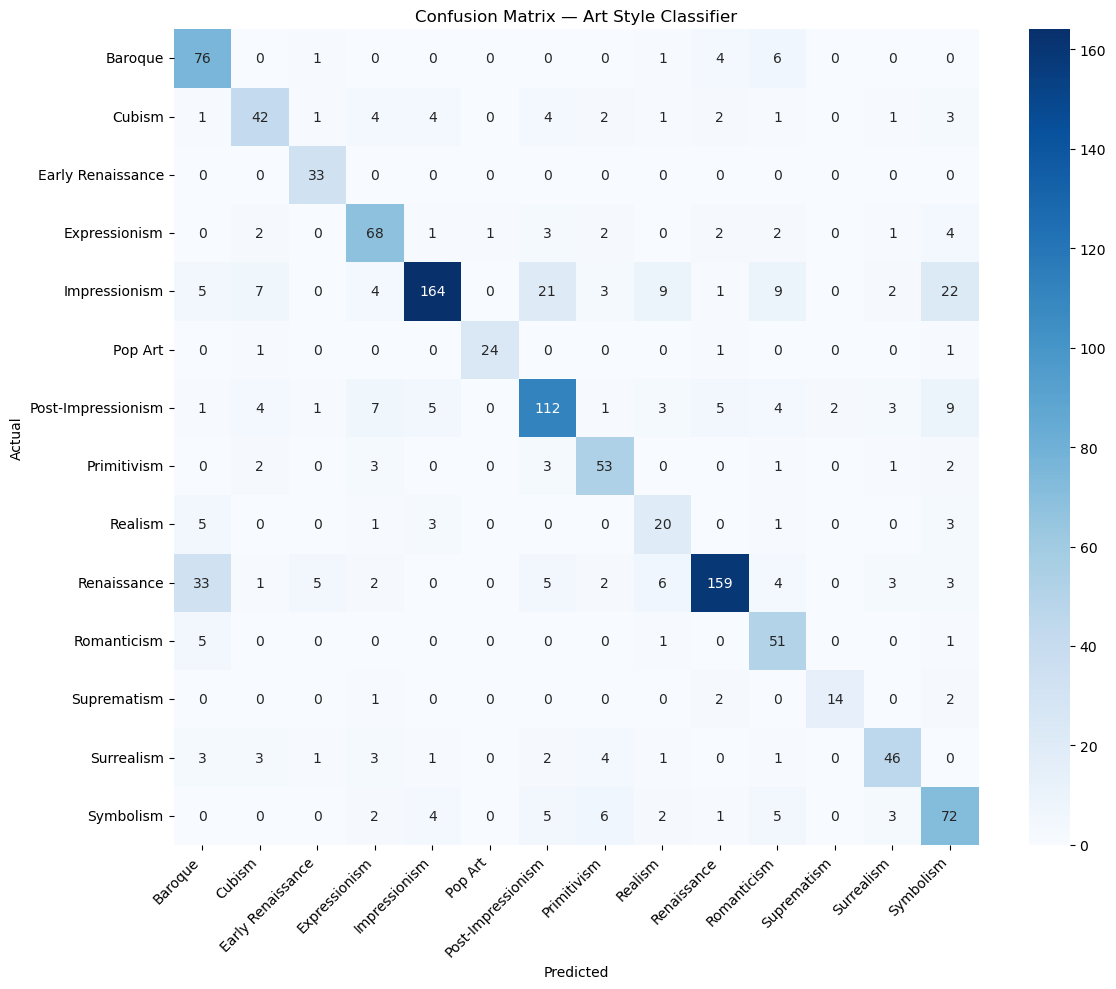

In [28]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=style_names,
    yticklabels=style_names,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Art Style Classifier")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

We have a strong diagonal which implies good recall... There is a cross over for renaissance->barouque, impressionism->post-impressionism, impressionism->symbolism which I think is fine. 

## Saving data for future kernels w/o having to train again

In [29]:
# Save training history
with open("artifacts/training_history.json", "w") as f:
    json.dump(history, f, indent=2)

# Save label maps
with open("data/style_labels.json", "w") as f:
    json.dump(style_to_idx, f, indent=2)

# Save model architecture config so you can rebuild it identically
model_config = {
    "num_classes": num_classes,
    "backbone": "efficientnet_b0",
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
}
with open("artifacts/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

print("Saved:")
print("  artifacts/best_model.pt")
print("  artifacts/training_history.json")
print("  artifacts/model_config.json")
print("  data/style_labels.json")
print("  data/train.csv / val.csv / test.csv")

Saved:
  artifacts/best_model.pt
  artifacts/training_history.json
  artifacts/model_config.json
  data/style_labels.json
  data/train.csv / val.csv / test.csv


In [30]:
# Confirm the saved model loads cleanly
test_model = ArtStyleClassifier(num_classes=num_classes).to(device)
test_model.load_state_dict(torch.load("artifacts/best_model.pt", map_location=device))
test_model.eval()
print(f"✓ Model loads cleanly — {num_classes} classes")
print(f"✓ Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")

✓ Model loads cleanly — 14 classes
✓ Best epoch: 8, Best val loss: 0.8063


In [ ]:
# Resume cell:  run this at the start of future sessions
with open("data/style_labels.json", "r") as f:
    style_to_idx = json.load(f)
idx_to_style = {i: s for s, i in style_to_idx.items()}

with open("artifacts/model_config.json", "r") as f:
    model_config = json.load(f)

with open("artifacts/training_history.json", "r") as f:
    history = json.load(f)

device = torch.device("mps")
model = ArtStyleClassifier(num_classes=model_config["num_classes"]).to(device)
model.load_state_dict(torch.load("artifacts/best_model.pt", map_location=device))
model.eval()

print(f" Resumed — {model_config['num_classes']} classes, best epoch {model_config['best_epoch']}")

 Resumed — 14 classes, best epoch 8
